In [1]:
import stlrom as sr
import numpy as np

sr.Signal().set_BigM(5)

d1 = sr.STLDriver()
d1.parse_string(
"""
signal x
mu := x[t]>0
phi := ev_[0, 2] ( x[t]>0 )
""")
d1.add_sample([0., 0.1])  
d1.add_sample([0.5, 2])
d1.add_sample([1.5, 1])
d1.add_sample([3,2])

mu = d1.get_monitor('mu')
tr_mu = mu.formula   
st_mu = tr_mu.get_formula_string()

phi = d1.get_monitor('phi')
tr_phi = phi.formula   
st_phi= tr_phi.get_formula_string()



In [2]:
mu.set_eval_time(0,5)
mu.eval_rob()
print('z:')
print(tr_mu.z)
print('z_low:')
print(tr_mu.z_low)
print('z_up:')
print(tr_mu.z_up)

z:
begin_time: 0  end_time: 5
time:          0  value:        0.1  derivative:        3.8
time:        0.5  value:          2  derivative:         -1
time:        1.5  value:          1  derivative:     0.6667
time:          3  value:          2  derivative:          0
time:          5  value:          2  derivative:          0

z_low:
begin_time: 0  end_time: 5
time:          0  value:        0.1  derivative:        3.8
time:        0.5  value:          2  derivative:         -1
time:        1.5  value:          1  derivative:     0.6667
time:          3  value:          2  derivative:          0
time:          3  value:         -5  derivative:          0
time:          5  value:         -5  derivative:          0

z_up:
begin_time: 0  end_time: 5
time:          0  value:        0.1  derivative:        3.8
time:        0.5  value:          2  derivative:         -1
time:        1.5  value:          1  derivative:     0.6667
time:          3  value:          2  derivative:          0
t

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

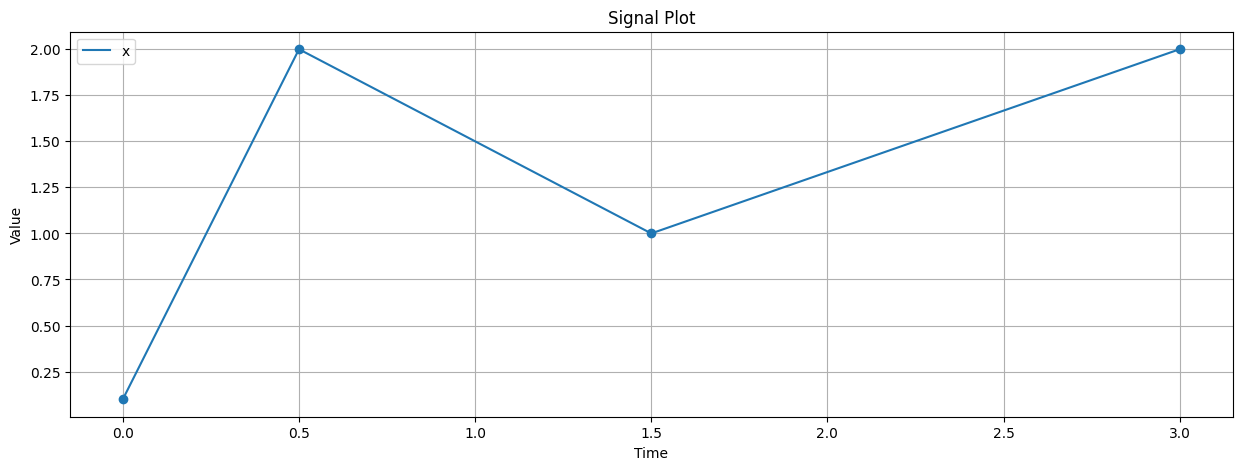

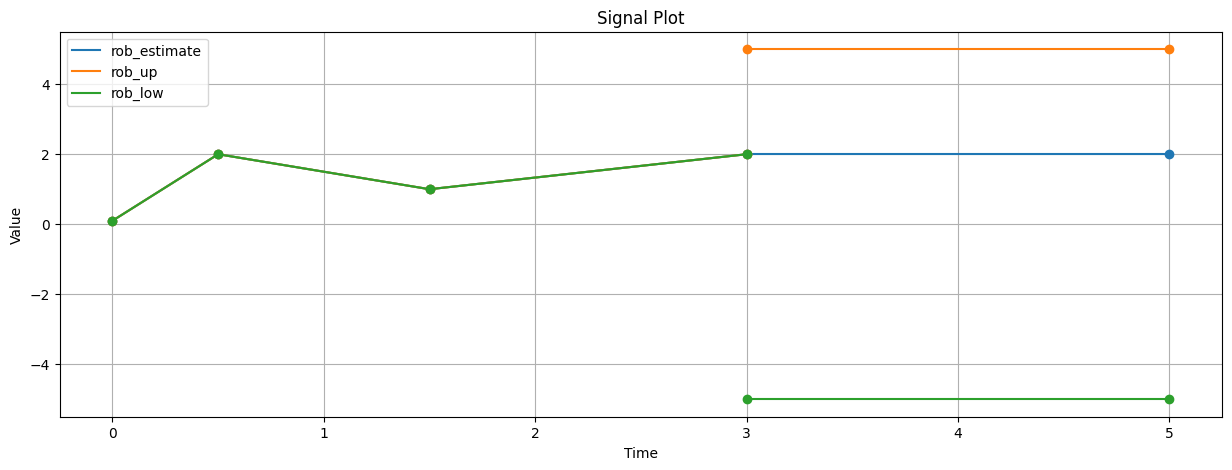

In [3]:
mu.plot_signal('x')
ax = tr_mu.z.plot(label='rob_estimate')
tr_mu.z_up.plot(label= 'rob_up',ax=ax)
tr_mu.z_low.plot(label= 'rob_low', ax=ax)


In [4]:
phi.eval_rob(0,3)
print('z:')
print(tr_phi.z)
print('z_low:')
print(tr_phi.z_low)
print('z_up:')
print(tr_phi.z_up)

z:
begin_time: 0  end_time: 3
time:          0  value:          2  derivative:          0
time:        0.5  value:          2  derivative:         -1
time:        0.7  value:        1.8  derivative:     0.6667
time:          1  value:          2  derivative:          0

z_low:
begin_time: 0  end_time: 3
time:          0  value:          2  derivative:          0
time:          1  value:          2  derivative:          0

z_up:
begin_time: 0  end_time: 3
time:          0  value:          2  derivative:          0
time:          1  value:          2  derivative:          0
time:          1  value:          5  derivative:          0



In [ ]:
phi.plot_signal('x')

ax = tr_phi.z.plot(label= 'estimate', ax=ax)

tr_phi.z_low.plot(label= 'z_low', ax=ax)
tr_phi.z_up.plot(label= 'z_up', ax=ax)

ax.set_title(tr_phi.get_formula_string())